# **Fund book: Multi-strategy sleeve blend under Halal screens**

This study asks whether a **single Halal book** — built from the sleeves that survived Phase 1A — compounds more steadily than any one of those sleeves on its own. After banned businesses and AAOIFI ratio screens, we combine:

1. **FCF quality** (paper 01) — top half of Halal names by free-cash-flow margin, cap-weighted, monthly
2. **ROIC compounders** (paper 02) — ROIC above 15% then top half by reinvestment, cap-weighted, monthly
3. **Dual-momentum regime** (paper 04) — top quintile 12–1 relative strength; **that sleeve** holds cash when SPY is below its 200-day SMA
4. **Optional SUE satellite** (paper 06) — robust SUE `> 2σ`, 21-day event hold, small sleeve weight

Weights are explicit. The core book shares a **monthly rebalance calendar**. High-beta (paper 05) stays out: it is a risk sleeve, not a steady-growth core. Whole-book SMA throttling and hard name caps are papers **09** and **08**; this notebook reports concentration honestly and runs one uncapped blend.

**White-paper question:** after Halal screens, does the blend beat any single sleeve on **drawdown-adjusted compounding** (Calmar, max drawdown, Sharpe) — or is it the same mega-cap tech book counted three times?

**What this notebook does, in plain terms:** load the frozen live rules from `Research/sleeves`, fetch one Halal universe with local `halalquant`, run each sleeve alone, then run two blends (core vs core+SUE) against SPY and SPUS.


## Setup

Install the **local** `halalquant` repo (`Development/halalquant`) when it is present, plus plotting libraries and DuckDB (needed for `cache=True`). Add `Research/` to `sys.path` so `sleeves` imports.

`FAST_MODE = True` uses ~60 names (smoke test). Set it `False` for the paper. Performance stats start on the first invested day, not on `START`.

Prices start earlier than `START` so 12–1 momentum and the 200-day SMA have history.

Pass `cache=True` into `halalquant` so a prior `prepare_dataset()` / DuckDB store is reused. Set `WARM_CACHE = True` once if you want this notebook to build that store (slow, rate-limited).

In zsh, quote the extra: `python3.11 -m pip install -e '.[cache]'` from the `halalquant` folder. Bare `pip install -e .` does **not** install DuckDB.

**Restart the kernel** after the first setup run so imports pick up DuckDB and the editable local package.


In [1]:
import os
import subprocess
import sys
from datetime import date
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/07-book-construction"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["yfinance", "matplotlib", "requests", "pyarrow", "duckdb"]

# Cache extras (duckdb) are optional in pyproject. zsh also glob-expands [cache]
# unless quoted — always install through this cell's sys.executable.
if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    hq_src = str(HQ_ROOT)
    if hq_src not in sys.path:
        sys.path.insert(0, hq_src)
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "halalquant[cache]"] + PIP_DEPS,
        cwd=str(NB_DIR),
        check=False,
    )

subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)

research_src = str(RESEARCH_ROOT)
if research_src not in sys.path:
    sys.path.insert(0, research_src)

import importlib
import sleeves
import sleeves.fundamentals
import sleeves.select
import sleeves.lab
importlib.reload(sleeves.fundamentals)
importlib.reload(sleeves.select)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from sleeves import FrozenRules, Lab, calc_performance_stats, run_sleeve, stats_table, attach_sue, fetch_earnings_history
from sleeves.universe import apply_sector_screen, load_sp500_tickers
from sleeves.weighting import collapse_share_classes

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Backtest configuration ---
START = "2019-12-19"         # SPUS live; covers 2020 crash + 2022 bear
END = "2024-12-31"
PRICE_START = "2018-01-01"   # warmup for 12–1 momentum and 200-day SMA
REBALANCE_FREQ = "ME"
FAST_MODE = False            # True → ~60 names; False → full eligible S&P 500
WARM_CACHE = False           # True → hq.prepare_dataset once (slow)
INCLUDE_SUE = True           # optional PEAD satellite
RISK_FREE_RATE = 0.02
COST_BPS = 10
FILING_LAG_DAYS = 90

CORE_WEIGHTS = {
    "fcf_quality": 0.40,
    "roic": 0.40,
    "dual_momentum": 0.20,
}
SUE_WEIGHTS = {
    "fcf_quality": 0.35,
    "roic": 0.35,
    "dual_momentum": 0.20,
    "sue": 0.10,
}

STRATEGY_LABEL = "Halal sleeve blend"
SUE_BLEND_LABEL = "Blend + SUE satellite"
CORE_SLEEVES = ("fcf_quality", "roic", "dual_momentum")

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",
}

CACHE_DIR = NB_DIR / "cache"
FIG_DIR = NB_DIR / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"notebook dir: {NB_DIR}")
print(f"halalquant v{hq.__version__} from {Path(hq.__file__).resolve().parent.parent}")
print(f"sleeves from {RESEARCH_ROOT / 'sleeves'}")
print(f"Window: {START} → {END}  FAST_MODE={FAST_MODE}  INCLUDE_SUE={INCLUDE_SUE}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction
halalquant v0.1.0 from /Users/raoabdul/Documents/Development/halalquant
sleeves from /Users/raoabdul/Documents/Development/Monterey-Finance/Research/sleeves
Window: 2019-12-19 → 2024-12-31  FAST_MODE=False  INCLUDE_SUE=True


## Step 1 — Shared Halal universe

Same starting list as papers 01–06: current S&P 500, then `halalquant` activity screens (banks, alcohol, gambling, weapons, …). Financial-ratio AAOIFI tests run **point-in-time at each rebalance** inside the sleeve selectors, not once up front.

**What the code cell does:**
- `load_sp500_tickers()` — Wikipedia list with an offline fallback
- `apply_sector_screen()` — drop banned businesses
- `FAST_MODE` keeps a short prefix for a smoke test


In [ ]:
raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, activity_labels = apply_sector_screen(raw_universe)

print(f"Raw universe:        {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")
display(sector_audit.head(8) if not sector_audit.empty else sector_audit)


Raw universe:        503 tickers
After sector screen: 439 tickers
Removed by sector:   64


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AXP,conventional banking,excluded business activity
4,AIG,conventional insurance,excluded business activity
5,AON,conventional insurance,excluded business activity
6,ACGL,conventional insurance,excluded business activity
7,AJG,conventional insurance,excluded business activity


## Step 2 — Frozen live rules and blend weights

`FrozenRules` copies the paper 01 / 02 / 04 / 06 live knobs. This paper does **not** hunt new factors. It only changes **how sleeves sit in one NAV**.

| Sleeve | Trigger | Weight (core) | Weight (with SUE) |
| --- | --- | --- | --- |
| FCF quality | month-end | 40% | 35% |
| ROIC | month-end | 40% | 35% |
| Dual momentum | month-end; cash if SPY < 200-day SMA | 20% | 20% |
| SUE PEAD | event-time, 21-day hold | 0% | 10% |

When dual momentum is in cash, its 20% is **not** forced into the other sleeves as extra risk-on size in the logging of that sleeve — `SleeveBook` renormalizes whatever sleeves still have holdings. That is a blend mechanic, not a whole-book throttle (paper 09).

`name_cap=None` and `throttle=None` keep paper 07 honest: we measure the raw blend before caps and a book-level SMA.


In [3]:
rules = (
    FrozenRules()
    .with_book(
        sleeve_weights=CORE_WEIGHTS,
        name_cap=None,
        throttle=None,
        collapse_share_classes=True,
        cost_bps=COST_BPS,
        risk_free_rate=RISK_FREE_RATE,
        rebalance_freq=REBALANCE_FREQ,
    )
)

print("AAOIFI debt cap:", rules.aaoifi.debt_threshold)
print("FCF keep quantile / min holdings:", rules.fcf.keep_quantile, rules.fcf.min_holdings)
print("ROIC floor / keep quantile:", rules.roic.roic_min, rules.roic.keep_quantile)
print("Dual-mom SMA / keep quantile:", rules.dual_momentum.sma_window, rules.dual_momentum.keep_quantile)
print("SUE threshold / hold days:", rules.sue.sue_threshold, rules.sue.hold_trading_days)
print("Core weights:", CORE_WEIGHTS)
print("SUE-blend weights:", SUE_WEIGHTS)


AAOIFI debt cap: 0.3
FCF keep quantile / min holdings: 0.5 20
ROIC floor / keep quantile: 0.15 0.5
Dual-mom SMA / keep quantile: 200 0.2
SUE threshold / hold days: 2.0 21
Core weights: {'fcf_quality': 0.4, 'roic': 0.4, 'dual_momentum': 0.2}
SUE-blend weights: {'fcf_quality': 0.35, 'roic': 0.35, 'dual_momentum': 0.2, 'sue': 0.1}


## Step 3 — One data pull (local `halalquant`)

FCF margin now uses `free_cash_flow` on `hq.get_financial_metrics` (SEC EDGAR when a CIK exists). That replaces the Yahoo cash-flow loop from paper 01.

ROIC still needs invested capital and reinvestment, which are not on the metrics panel — we build a lagged Yahoo history once and cache it as parquet.

SUE still needs the Yahoo earnings calendar (optional satellite).

**What the code cell does:**
- Optionally `hq.prepare_dataset(...)` if `WARM_CACHE` is on
- Monthly AAOIFI metrics + adjusted prices with `cache=True`
- ROIC history (cached)
- Optional SUE events (cached)


In [4]:
all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))

if WARM_CACHE:
    print("Warming local halalquant dataset (slow first time) …")
    hq.prepare_dataset(
        eligible_universe,
        start=PRICE_START,
        end=END,
        freq=REBALANCE_FREQ,
        cache=True,
    )

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(
    eligible_universe,
    start=START,
    end=END,
    freq=REBALANCE_FREQ,
    cache=True,
)
print(f"  {metrics.shape[0]} snapshot rows, {metrics['symbol'].nunique()} symbols")
if "free_cash_flow" in metrics.columns:
    n_fcf = pd.to_numeric(metrics["free_cash_flow"], errors="coerce").notna().sum()
    print(f"  free_cash_flow populated on {n_fcf} rows")

print("Downloading prices …")
prices = hq.download(all_symbols, start=PRICE_START, end=END, cache=True)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

display(metrics.head())


Fetching point-in-time AAOIFI metrics …
  25539 snapshot rows, 430 symbols
  free_cash_flow populated on 22659 rows
  441 symbols, 1761 trading days


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,...,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio,ebitda,operating_cash_flow,capital_expenditure,free_cash_flow
0,A,2019-12-31,2019-10-31,2019-12-19,2.407000e+09,1.382000e+09,0.0,930000000.0,1.382000e+09,2.712858e+10,...,0.106311,0.061039,0.102115,5.163000e+09,36000000.0,0.006973,1.179000e+09,1.021000e+09,155000000.0,866000000.0
1,A,2020-01-31,2019-10-31,2019-12-19,2.407000e+09,1.382000e+09,0.0,930000000.0,1.382000e+09,2.625408e+10,...,0.105368,0.060498,0.101209,5.163000e+09,36000000.0,0.006973,1.179000e+09,1.021000e+09,155000000.0,866000000.0
2,A,2020-02-29,2019-10-31,2019-12-19,2.407000e+09,1.382000e+09,0.0,930000000.0,1.382000e+09,2.450826e+10,...,0.104638,0.060079,0.100508,5.163000e+09,36000000.0,0.006973,1.179000e+09,1.021000e+09,155000000.0,866000000.0
3,A,2020-03-31,2019-10-31,2019-12-19,2.407000e+09,1.382000e+09,0.0,930000000.0,1.382000e+09,2.277516e+10,...,0.104468,0.059981,0.100345,5.163000e+09,36000000.0,0.006973,1.179000e+09,1.021000e+09,155000000.0,866000000.0
4,A,2020-04-30,2019-10-31,2019-12-19,2.407000e+09,1.382000e+09,0.0,930000000.0,1.382000e+09,2.437788e+10,...,0.103903,0.059657,0.099802,5.163000e+09,36000000.0,0.006973,1.179000e+09,1.021000e+09,155000000.0,866000000.0


### ROIC history (paper 02 live rule)

NOPAT / invested capital and reinvestment rate, with a 90-day publication lag. Cached under `cache/roic_history.parquet`.


In [5]:
EBIT_ALIASES = ("EBIT", "Operating Income", "OperatingIncome")
REVENUE_ALIASES = ("Total Revenue", "Operating Revenue", "TotalRevenue")
RD_ALIASES = ("Research And Development", "ResearchDevelopment")
TAX_ALIASES = ("Tax Rate For Calcs", "Tax Provision", "TaxProvision")
PRETAX_ALIASES = ("Pretax Income", "PretaxIncome")
PPE_ALIASES = ("Net PPE", "NetPPE", "Properties Plant And Equipment Net")
CA_ALIASES = ("Current Assets", "CurrentAssets")
CL_ALIASES = ("Current Liabilities", "CurrentLiabilities")
CASH_ALIASES = ("Cash And Cash Equivalents", "CashCashEquivalentsAndShortTermInvestments", "Cash And Equivalents")
CAPEX_ALIASES = ("Capital Expenditure", "CapitalExpenditures")
DA_ALIASES = ("Depreciation And Amortization", "DepreciationAmortizationDepletion")
NWC_ALIASES = ("Change In Working Capital", "ChangeInWorkingCapital")


def _cell(frame, aliases, col):
    if frame is None or col is None:
        return np.nan
    for name in aliases:
        if name in frame.index:
            val = frame.at[name, col]
            try:
                return float(val)
            except (TypeError, ValueError):
                return np.nan
    return np.nan


def _aligned_col(frame, period_end, tolerance_days=45):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    target = pd.Timestamp(period_end)
    cols = list(frame.columns)
    dated = [(c, abs((pd.Timestamp(c) - target).days)) for c in cols]
    dated = [(c, d) for c, d in dated if d <= tolerance_days]
    if not dated:
        return None
    dated.sort(key=lambda x: x[1])
    return dated[0][0]


def _effective_tax_rate(income, col):
    tax = _cell(income, TAX_ALIASES, col)
    pretax = _cell(income, PRETAX_ALIASES, col)
    if pd.notna(tax) and 0 <= tax <= 1:
        return float(tax)
    if pd.notna(tax) and pd.notna(pretax) and pretax != 0:
        rate = float(tax) / float(pretax)
        if 0 <= rate <= 1:
            return rate
    return 0.21


def _invested_capital(balance, col):
    ppe = _cell(balance, PPE_ALIASES, col)
    ca = _cell(balance, CA_ALIASES, col)
    cl = _cell(balance, CL_ALIASES, col)
    cash = _cell(balance, CASH_ALIASES, col)
    if pd.isna(ppe):
        ppe = 0.0
    nwc = 0.0
    if pd.notna(ca) and pd.notna(cl):
        cash = 0.0 if pd.isna(cash) else float(cash)
        nwc = max(float(ca) - cash - float(cl), 0.0)
    operating = float(ppe) + nwc
    return float(operating) if operating > 0 else np.nan


def build_roic_history(symbols, filing_lag_days=FILING_LAG_DAYS) -> pd.DataFrame:
    rows = []
    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 25 == 0 or i == n_symbols:
            print(f"  ROIC history {i}/{n_symbols}", flush=True)
        try:
            ticker = yf.Ticker(symbol)
            income = ticker.income_stmt
            balance = ticker.balance_sheet
            cashflow = ticker.cashflow
        except Exception:
            continue
        if income is None or not isinstance(income, pd.DataFrame) or income.empty:
            continue
        for period_end in reversed(list(income.columns)):
            bs_col = _aligned_col(balance, period_end)
            cf_col = _aligned_col(cashflow, period_end)
            ebit = _cell(income, EBIT_ALIASES, period_end)
            if pd.isna(ebit):
                continue
            rd = _cell(income, RD_ALIASES, period_end)
            rd = 0.0 if pd.isna(rd) else float(rd)
            nopat = float(ebit) * (1.0 - _effective_tax_rate(income, period_end))
            ic = _invested_capital(balance, bs_col) if bs_col is not None else np.nan
            roic = nopat / ic if pd.notna(ic) and ic > 0 else np.nan
            capex = _cell(cashflow, CAPEX_ALIASES, cf_col) if cf_col is not None else np.nan
            da = _cell(cashflow, DA_ALIASES, cf_col) if cf_col is not None else np.nan
            nwc_cf = _cell(cashflow, NWC_ALIASES, cf_col) if cf_col is not None else np.nan
            capex_outlay = abs(float(capex)) if pd.notna(capex) else np.nan
            da_val = 0.0 if pd.isna(da) else float(da)
            delta_nwc = np.nan if pd.isna(nwc_cf) else -float(nwc_cf)
            reinvestment = np.nan
            if pd.notna(capex_outlay):
                nwc_term = 0.0 if pd.isna(delta_nwc) else float(delta_nwc)
                reinvestment = capex_outlay - da_val + nwc_term + rd
            reinvestment_rate = (
                reinvestment / nopat
                if pd.notna(reinvestment) and pd.notna(nopat) and nopat != 0
                else np.nan
            )
            report_ts = pd.Timestamp(period_end).normalize()
            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": (report_ts + pd.Timedelta(days=filing_lag_days)).date(),
                    "nopat": nopat,
                    "invested_capital": ic,
                    "roic": roic,
                    "reinvestment": reinvestment,
                    "reinvestment_rate": reinvestment_rate,
                    "rd": rd,
                }
            )
    return pd.DataFrame(rows)


roic_path = CACHE_DIR / "roic_history.parquet"
if roic_path.exists() and not FAST_MODE:
    roic_history = pd.read_parquet(roic_path)
    print(f"Loaded cached ROIC history: {roic_path}")
else:
    print("Building ROIC history …")
    roic_history = build_roic_history(eligible_universe)
    if not FAST_MODE and not roic_history.empty:
        roic_history.to_parquet(roic_path, index=False)
        print(f"  wrote {roic_path}")

print(
    f"  {0 if roic_history.empty else roic_history['symbol'].nunique()} symbols with ROIC rows"
)


Loaded cached ROIC history: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction/cache/roic_history.parquet
  431 symbols with ROIC rows


### SUE events (optional satellite)

Robust SUE uses only **prior** forecast errors. Cached under `cache/sue_events.parquet`. Skip with `INCLUDE_SUE = False`.


In [6]:
sue_path = CACHE_DIR / "sue_events.parquet"
if not INCLUDE_SUE:
    sue_events = pd.DataFrame()
    print("INCLUDE_SUE=False — satellite off")
elif sue_path.exists() and not FAST_MODE:
    sue_events = pd.read_parquet(sue_path)
    print(f"Loaded cached SUE events: {sue_path}")
else:
    print("Fetching earnings dates …")
    earnings_raw = fetch_earnings_history(eligible_universe)
    print(f"  parsed prints: {0 if earnings_raw.empty else len(earnings_raw)}")
    sue_events = (
        attach_sue(earnings_raw, min_prior=rules.sue.min_prior_errors)
        if not earnings_raw.empty
        else pd.DataFrame()
    )
    if not FAST_MODE and not sue_events.empty:
        sue_events.to_parquet(sue_path, index=False)
        print(f"  wrote {sue_path}")

if sue_events.empty:
    print("  no SUE events — core blend will run without the satellite")
else:
    usable = int(sue_events["sue"].notna().sum()) if "sue" in sue_events.columns else 0
    print(f"  {usable} prints with usable SUE")


Loaded cached SUE events: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction/cache/sue_events.parquet
  17504 prints with usable SUE


## Step 4 — Build the lab and inspect the last rebalance

`Lab.from_frames` is the reusable session: one metrics panel, one price panel, frozen rules. `evaluate(as_of)` shows which sleeves are **triggered** that day (monthly book vs SMA-off cash vs SUE window).


In [7]:
lab = Lab.from_frames(
    metrics=metrics,
    prices=prices,
    rules=rules,
    roic_history=roic_history,
    sue_events=sue_events,
    start=START,
    end=END,
)

rebalance_dates = sorted(pd.to_datetime(metrics["as_of"].dropna().unique()).date)
last_as_of = rebalance_dates[-1]
sue_on = INCLUDE_SUE and (not sue_events.empty) and ("sue" in sue_events.columns)
state = lab.evaluate(last_as_of, sleeves=CORE_SLEEVES + (("sue",) if sue_on else ()))

print(f"Rebalance dates: {len(rebalance_dates)}  last={last_as_of}")
print(f"Regime: {state[CORE_SLEEVES[0]].extras['regime'].reason}")
for sid, st in state.items():
    print(f"  {st.label:28s}  triggered={st.triggered!s:5s}  n={st.n_holdings:3d}  {st.reason}")

print("\nCore blend holdings (largest weights):")
blend_now = lab.book(sleeve_weights=CORE_WEIGHTS, name_cap=None, throttle=None).blended_holdings(last_as_of)
display(blend_now.head(15) if not blend_now.empty else blend_now)


Rebalance dates: 61  last=2024-12-31
Regime: SPY above 200-day SMA
  Halal FCF quality             triggered=True   n=121  rebalance date
  Halal ROIC compounders        triggered=True   n= 83  rebalance date
  Halal dual momentum           triggered=True   n= 56  SPY above 200-day SMA
  Halal SUE > 2σ PEAD           triggered=False  n=  0  no qualifying prints in hold window

Core blend holdings (largest weights):


,symbol,weight
116,MSFT,0.144494
108,META,0.112013
73,GOOG,0.109422
1,AAPL,0.071544
18,AVGO,0.049490
159,TSLA,0.035004
127,ORCL,0.033407
177,WMT,0.019526
101,LLY,0.018977
90,JNJ,0.017075


## Step 5 — Run each sleeve, then the blends

Each standalone sleeve is 100% of NAV with **no** book throttle. The live blend uses `CORE_WEIGHTS` on the shared monthly calendar. The SUE variant adds the event satellite. A robustness path turns `throttle="spy_sma"` on the **whole** NAV — that is paper 09 preview, not the live 07 rule.


In [8]:
sleeve_returns = {}
sleeve_logs = {}

for sid in CORE_SLEEVES:
    print(f"Running {sid} …")
    ret, log = run_sleeve(lab, sid, start=START)
    sleeve_returns[sid] = ret
    sleeve_logs[sid] = log
    live = ret["return"].notna().sum()
    print(f"  {live} live days, {0 if log.empty else log['as_of'].nunique()} rebalance snapshots")

print("Running core blend …")
core_book = lab.book(sleeve_weights=CORE_WEIGHTS, name_cap=None, throttle=None)
core_returns, core_log = core_book.run(start=START)

sue_returns = sue_log = None
if INCLUDE_SUE and not sue_events.empty:
    print("Running blend + SUE …")
    sue_book = lab.book(sleeve_weights=SUE_WEIGHTS, name_cap=None, throttle=None)
    sue_returns, sue_log = sue_book.run(start=START)

print("Running whole-book SMA throttle preview (paper 09, not live 07) …")
throttled_book = lab.book(sleeve_weights=CORE_WEIGHTS, name_cap=None, throttle="spy_sma")
throttled_returns, throttled_log = throttled_book.run(start=START)

print("Done.")


Running fcf_quality …
  1259 live days, 61 rebalance snapshots
Running roic …
  524 live days, 26 rebalance snapshots
Running dual_momentum …
  1259 live days, 48 rebalance snapshots
Running core blend …
Running blend + SUE …
Running whole-book SMA throttle preview (paper 09, not live 07) …
Done.


## Step 6 — Empirical performance

Headline numbers use the **live window** (first invested day through `END`). Sharpe and Sortino use a 2% risk-free rate. Max drawdown is peak-to-trough on the growth curve.

The mandate question is **Calmar and max drawdown**, not whether the blend has the highest CAGR.


In [9]:
def to_series(frame, col="return"):
    s = frame.dropna(subset=[col]).set_index("date")[col].astype(float)
    s = s[s.index >= pd.Timestamp(START)]
    return s


bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)

series_map = {
    STRATEGY_LABEL: to_series(core_returns),
}
if sue_returns is not None:
    series_map[SUE_BLEND_LABEL] = to_series(sue_returns)
series_map["Throttle preview (SMA on NAV)"] = to_series(throttled_returns)
for sid, frame in sleeve_returns.items():
    series_map[{
        "fcf_quality": "FCF quality",
        "roic": "ROIC compounders",
        "dual_momentum": "Dual momentum",
    }[sid]] = to_series(frame)

for name, ticker in BENCHMARKS.items():
    if ticker in bench_ret.columns:
        series_map[name] = bench_ret[ticker].dropna()
        series_map[name] = series_map[name][series_map[name].index >= pd.Timestamp(START)]

perf = stats_table(series_map, rf=RISK_FREE_RATE)
show = perf.copy()
for col in ("CAGR", "Volatility", "Max Drawdown"):
    show[col] = show[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
for col in ("Sharpe", "Sortino", "Calmar"):
    show[col] = show[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
display(show)

# Align to common live dates for a fair Calmar horse-race
common_index = series_map[STRATEGY_LABEL].dropna().index
for s in series_map.values():
    common_index = common_index.intersection(s.dropna().index)
aligned = {k: v.reindex(common_index).dropna() for k, v in series_map.items()}
aligned = {k: v for k, v in aligned.items() if len(v) > 60}
fair = stats_table(aligned, rf=RISK_FREE_RATE).sort_values("Calmar", ascending=False)
print("\nSame-window ranking by Calmar (common live dates):")
fair_show = fair.copy()
for col in ("CAGR", "Volatility", "Max Drawdown"):
    fair_show[col] = fair_show[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
for col in ("Sharpe", "Sortino", "Calmar"):
    fair_show[col] = fair_show[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
display(fair_show)


,Strategy,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
0,Halal sleeve blend,14.6%,23.0%,0.62,0.82,-29.6%,0.49
1,Blend + SUE satellite,17.3%,22.7%,0.73,0.94,-31.0%,0.56
2,Throttle preview (SMA on NAV),16.5%,14.5%,0.99,1.16,-11.5%,1.44
3,FCF quality,15.8%,22.4%,0.68,0.89,-29.0%,0.54
4,ROIC compounders,24.5%,16.8%,1.27,1.82,-14.6%,1.68
5,Dual momentum,5.8%,18.1%,0.29,0.35,-30.4%,0.19
6,S&P 500,14.7%,20.9%,0.67,0.81,-33.7%,0.44
7,Halal (SPUS),17.8%,21.6%,0.77,1.02,-30.8%,0.58



Same-window ranking by Calmar (common live dates):


,Strategy,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
1,Blend + SUE satellite,27.2%,14.9%,1.55,2.28,-10.1%,2.70
3,FCF quality,25.3%,14.5%,1.48,2.18,-9.5%,2.65
7,Halal (SPUS),27.9%,15.5%,1.54,2.29,-11.5%,2.43
6,S&P 500,23.0%,13.3%,1.48,2.18,-10.0%,2.31
0,Halal sleeve blend,23.9%,15.3%,1.35,1.94,-11.5%,2.08
2,Throttle preview (SMA on NAV),22.0%,13.9%,1.36,1.81,-11.5%,1.92
4,ROIC compounders,24.9%,16.8%,1.29,1.85,-14.6%,1.71
5,Dual momentum,9.9%,16.5%,0.53,0.73,-15.3%,0.64


### Equity curves, drawdowns, calendar years


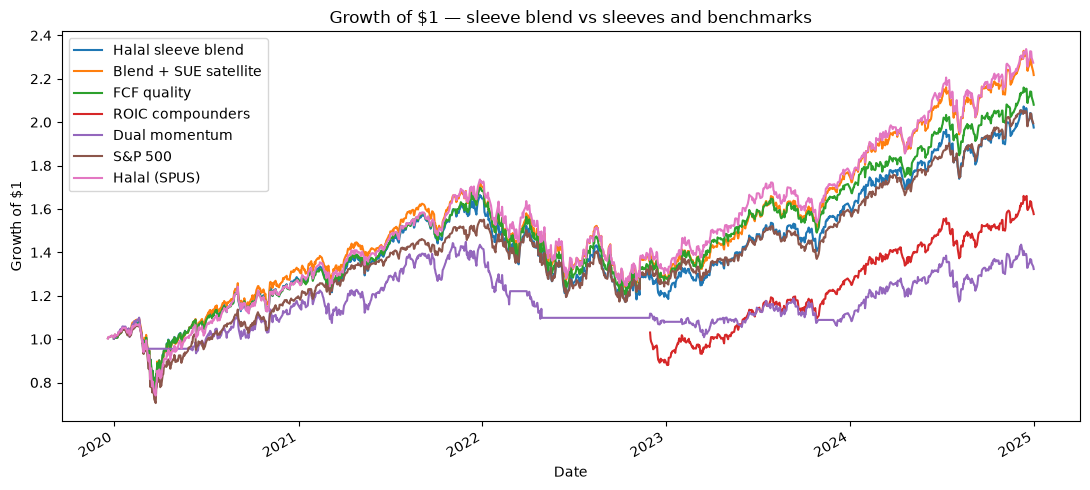

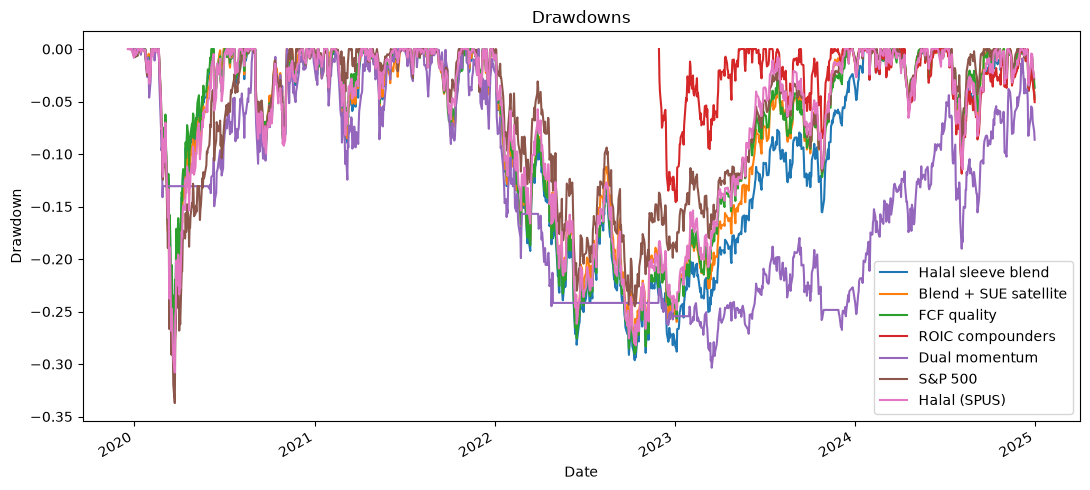

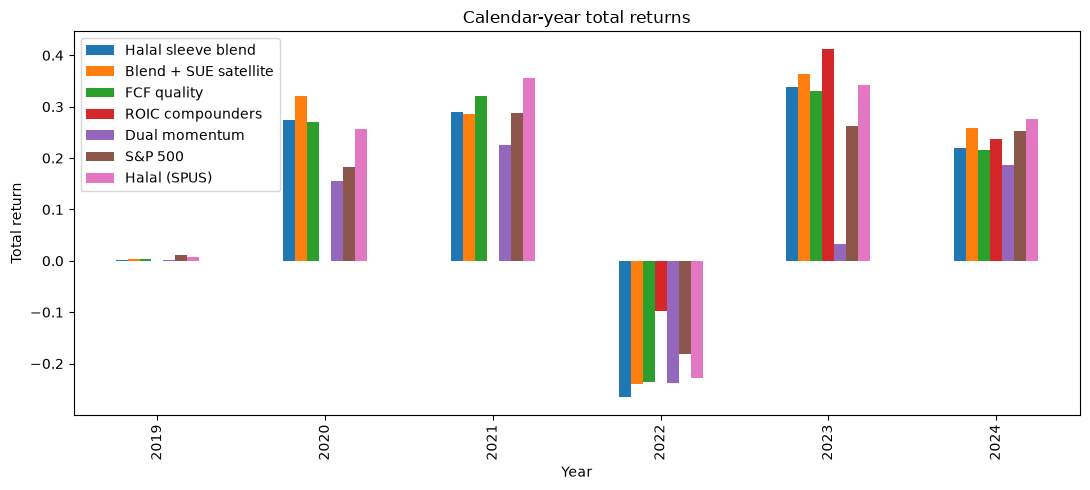

,Halal sleeve blend,Blend + SUE satellite,FCF quality,ROIC compounders,Dual momentum,S&P 500,Halal (SPUS)
year,,,,,,,
2019,0.2%,0.3%,0.3%,0.0%,0.2%,1.2%,0.8%
2020,27.5%,32.0%,27.1%,0.0%,15.6%,18.3%,25.7%
2021,28.9%,28.6%,32.0%,0.0%,22.5%,28.7%,35.6%
2022,-26.6%,-24.1%,-23.6%,-9.8%,-23.9%,-18.2%,-22.8%
2023,33.9%,36.3%,33.0%,41.3%,3.3%,26.2%,34.2%
2024,21.9%,25.8%,21.6%,23.7%,18.6%,25.3%,27.7%


In [10]:
plot_keys = [STRATEGY_LABEL, "FCF quality", "ROIC compounders", "Dual momentum", "S&P 500", "Halal (SPUS)"]
if SUE_BLEND_LABEL in series_map:
    plot_keys.insert(1, SUE_BLEND_LABEL)

equity = pd.DataFrame({k: (1 + series_map[k]).cumprod() for k in plot_keys if k in series_map})
ax = equity.plot(figsize=(11, 5), title="Growth of $1 — sleeve blend vs sleeves and benchmarks")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIG_DIR / "equity-curves.png", dpi=140)
plt.show()

dd = equity / equity.cummax() - 1
ax = dd.plot(figsize=(11, 5), title="Drawdowns")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIG_DIR / "drawdowns.png", dpi=140)
plt.show()

cal = pd.DataFrame({k: series_map[k] for k in plot_keys if k in series_map})
cal["year"] = cal.index.year
year_ret = (1 + cal.drop(columns=["year"])).groupby(cal["year"]).prod() - 1
ax = year_ret.plot(kind="bar", figsize=(11, 5), title="Calendar-year total returns")
ax.set_ylabel("Total return")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig(FIG_DIR / "calendar-year-returns.png", dpi=140)
plt.show()
display(year_ret.map(lambda x: f"{x:.1%}"))


## Step 7 — Is this diversification or Nvidia three times?

Paper 13 will go deeper. Here we only ask whether FCF and ROIC holdings overlap so much that a 40/40 split is a single quality cluster.


FCF ∩ ROIC: mean Jaccard=21.6%, mean overlap of A=29.4%


,as_of,n_a,n_b,n_overlap,overlap_of_a,overlap_of_b,jaccard
21,2024-08-31,114,78,40,0.350877,0.512821,0.263158
22,2024-09-30,115,79,41,0.356522,0.518987,0.267974
23,2024-10-31,116,79,41,0.353448,0.518987,0.266234
24,2024-11-30,116,79,41,0.353448,0.518987,0.266234
25,2024-12-31,120,82,41,0.341667,0.500000,0.254658


FCF ∩ Dual mom: mean Jaccard=16.7%, mean overlap of A=20.8%


,as_of,n_a,n_b,n_overlap,overlap_of_a,overlap_of_b,jaccard
43,2024-08-31,114,52,22,0.192982,0.423077,0.152778
44,2024-09-30,115,54,29,0.252174,0.537037,0.207143
45,2024-10-31,116,54,26,0.224138,0.481481,0.180556
46,2024-11-30,116,54,26,0.224138,0.481481,0.180556
47,2024-12-31,120,56,25,0.208333,0.446429,0.165563



Mean top-5 weight in the core blend: 44.2%
Last blend snapshot — top names:


,symbol,weight,as_of
8729,MSFT,0.144494,2024-12-31
8730,META,0.112013,2024-12-31
8731,GOOG,0.109422,2024-12-31
8732,AAPL,0.071544,2024-12-31
8733,AVGO,0.049490,2024-12-31
8734,TSLA,0.035004,2024-12-31
8735,ORCL,0.033407,2024-12-31
8736,WMT,0.019526,2024-12-31
8737,LLY,0.018977,2024-12-31
8738,JNJ,0.017075,2024-12-31


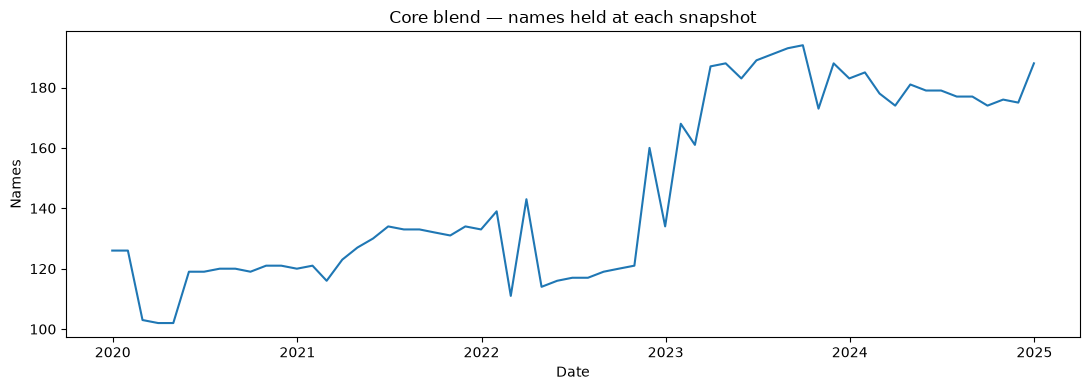

In [11]:
def overlap_table(log_a, log_b, label_a, label_b):
    rows = []
    dates = sorted(set(log_a["as_of"]) & set(log_b["as_of"]))
    for as_of in dates:
        a = set(log_a.loc[log_a["as_of"] == as_of, "symbol"])
        b = set(log_b.loc[log_b["as_of"] == as_of, "symbol"])
        if not a or not b:
            continue
        inter = a & b
        rows.append(
            {
                "as_of": as_of,
                "n_a": len(a),
                "n_b": len(b),
                "n_overlap": len(inter),
                "overlap_of_a": len(inter) / len(a),
                "overlap_of_b": len(inter) / len(b),
                "jaccard": len(inter) / len(a | b),
            }
        )
    out = pd.DataFrame(rows)
    print(f"{label_a} ∩ {label_b}: mean Jaccard={out['jaccard'].mean():.1%}, mean overlap of A={out['overlap_of_a'].mean():.1%}")
    return out


fcf_log = sleeve_logs["fcf_quality"]
roic_log = sleeve_logs["roic"]
mom_log = sleeve_logs["dual_momentum"]

if not fcf_log.empty and not roic_log.empty:
    ov_fr = overlap_table(fcf_log, roic_log, "FCF", "ROIC")
    display(ov_fr.tail())
if not fcf_log.empty and not mom_log.empty:
    ov_fm = overlap_table(fcf_log, mom_log, "FCF", "Dual mom")
    display(ov_fm.tail())

if not core_log.empty:
    w = core_log.copy()
    w["rank"] = w.groupby("as_of")["weight"].rank(ascending=False, method="first")
    top = w[w["rank"] <= 5]
    print("\nMean top-5 weight in the core blend:", f"{top.groupby('as_of')['weight'].sum().mean():.1%}")
    last = core_log[core_log["as_of"] == core_log["as_of"].max()].sort_values("weight", ascending=False)
    print("Last blend snapshot — top names:")
    display(last.head(10))

    holdings_n = core_log.groupby("as_of")["symbol"].nunique()
    ax = holdings_n.plot(figsize=(11, 4), title="Core blend — names held at each snapshot")
    ax.set_ylabel("Names")
    ax.set_xlabel("Date")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "holdings-count.png", dpi=140)
    plt.show()


## Step 8 — Turnover and a 10 bp cost check

One-way turnover is half the $\ell_1$ weight change between consecutive snapshots. Cost drag assumes `COST_BPS` per one-way turn.


,Item,Value
0,Snapshots,61
1,Annualized one-way turnover,166.0%
2,Assumed cost per one-way trade,10 bp
3,Estimated annual trading-cost drag,0.17%
4,CAGR gross,14.60%
5,CAGR net of costs (approx),14.43%


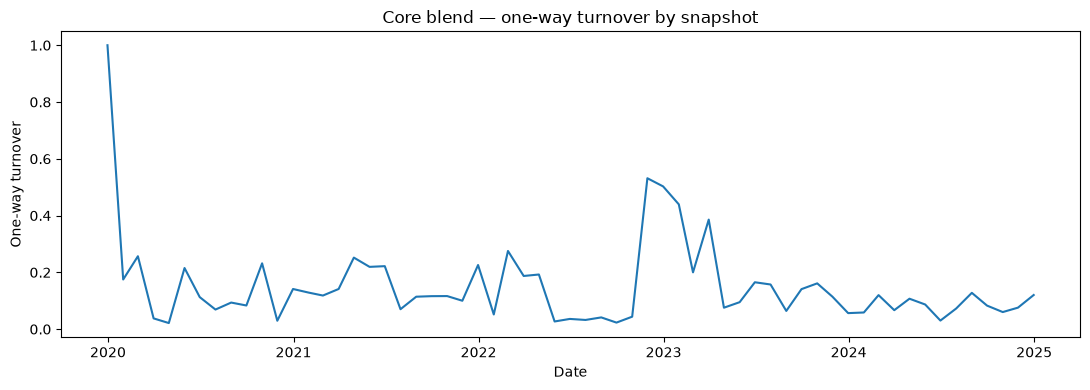

In [12]:
def one_way_turnover(log: pd.DataFrame) -> pd.Series:
    if log.empty:
        return pd.Series(dtype=float)
    piv = log.pivot_table(index="as_of", columns="symbol", values="weight", aggfunc="sum").fillna(0.0)
    turns = []
    prev = None
    for as_of, row in piv.iterrows():
        if prev is None:
            turns.append((as_of, 1.0))
        else:
            turns.append((as_of, 0.5 * float((row - prev).abs().sum())))
        prev = row
    return pd.Series({d: t for d, t in turns})


turn = one_way_turnover(core_log)
ann_turn = float(turn.iloc[1:].sum() / max((turn.index[-1] - turn.index[0]).days / 365.25, 1e-9)) if len(turn) > 1 else np.nan
drag = ann_turn * (COST_BPS / 1e4)
core_stats = calc_performance_stats(series_map[STRATEGY_LABEL], STRATEGY_LABEL, rf=RISK_FREE_RATE)
net_cagr = core_stats["CAGR"] - drag if pd.notna(core_stats["CAGR"]) and pd.notna(drag) else np.nan

friction = pd.DataFrame(
    {
        "Item": [
            "Snapshots",
            "Annualized one-way turnover",
            "Assumed cost per one-way trade",
            "Estimated annual trading-cost drag",
            "CAGR gross",
            "CAGR net of costs (approx)",
        ],
        "Value": [
            int(len(turn)),
            f"{ann_turn:.1%}" if pd.notna(ann_turn) else "—",
            f"{COST_BPS:.0f} bp",
            f"{drag:.2%}" if pd.notna(drag) else "—",
            f"{core_stats['CAGR']:.2%}" if pd.notna(core_stats["CAGR"]) else "—",
            f"{net_cagr:.2%}" if pd.notna(net_cagr) else "—",
        ],
    }
)
display(friction)

if not turn.empty:
    ax = turn.plot(figsize=(11, 4), title="Core blend — one-way turnover by snapshot")
    ax.set_ylabel("One-way turnover")
    ax.set_xlabel("Date")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "turnover.png", dpi=140)
    plt.show()


## Limitations

- **Common window.** FCF and ROIC papers were short bull samples. This blend is scored on 2019–2024 so 2020 and 2022 count. Sleeves can still be thin early if SEC/Yahoo history is missing.
- **Overlap.** A high FCF ∩ ROIC Jaccard means the 40/40 quality split is one cluster. Dual momentum is the only sleeve that can go to cash.
- **No name cap (yet).** Mega-caps can dominate. That is paper 08.
- **No book-level SMA (yet).** Dual momentum cash does not flatten the quality sleeves. The throttle preview is diagnostic only (paper 09).
- **SUE costs.** Event-time satellite turnover is higher than monthly quality. Net-of-cost Calmar is the fair satellite test.
- **Survivorship.** Current S&P 500 list, not point-in-time membership. Dual listings are collapsed in the blend (`GOOG`/`GOOGL`).
- **Exploratory.** In-sample relative to which sleeves were kept in Phase 1A. Not a live-return target.

**Keep / revise / kill for paper 07:** keep the blend as the working 1B book if its Calmar beats SPUS **and** beats the worst of the three core sleeves on max drawdown; otherwise treat 01+02 as one quality cluster and let paper 09 supply the drawdown brake.
